# Exploratory Data Analysis — Stock Sentiment

Profiles the validated ingestion output and produces the drift baselines that Phase 6 monitoring consumes.

**Inputs**
- `data/interim/validated.parquet` — output of the DVC `validate` stage
- `artifacts/baselines.json` — pre-computed drift baselines (for comparison)

**Outputs reviewed here**
- Class balance across labels
- Per-ticker / per-source volume
- Text length distribution (characters + word count)
- Missing values per column

This notebook is idempotent — running it against the same parquet always produces the same numbers.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path('../data/interim/validated.parquet')
BASELINES = Path('../artifacts/baselines.json')

df = pd.read_parquet(DATA)
print(f'Loaded {len(df):,} records with columns: {list(df.columns)}')
df.head(3)

Loaded 300 records with columns: ['id', 'source', 'ticker', 'text', 'timestamp', 'title', 'url', 'author', 'language', 'label']


,id,source,ticker,text,timestamp,title,url,author,language,label
0,seed-0031,seed,NVDA,"NVDA sees record user growth this quarter, bea...",2026-04-25T00:28:14Z,None,None,None,en,positive
1,seed-0233,seed,TSLA,Trading volume for TSLA in line with its 30-da...,2026-04-21T11:09:14Z,None,None,None,en,neutral
2,seed-0058,seed,TSLA,"TSLA sees record user growth this quarter, bea...",2026-04-25T06:29:14Z,None,None,None,en,positive


## Class balance

The model is trained on these proportions, so they become the baseline for the prediction-class-ratio drift check.

label
positive    110
neutral      95
negative     95
Name: count, dtype: int64


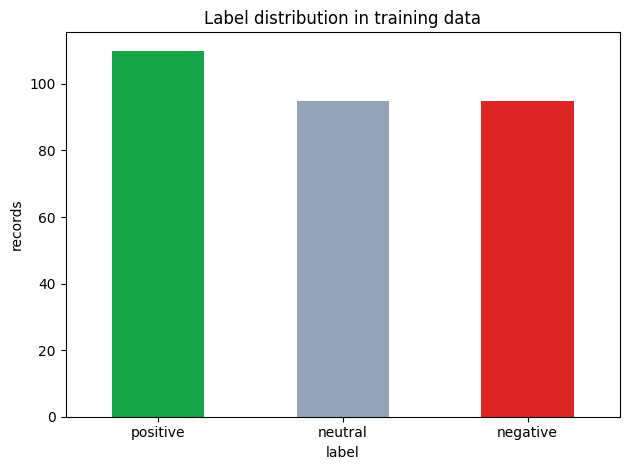

In [2]:
class_counts = df['label'].value_counts(dropna=False)
print(class_counts)
class_counts.plot.bar(rot=0, color=['#16a34a', '#94a3b8', '#dc2626'])
plt.title('Label distribution in training data')
plt.ylabel('records')
plt.tight_layout()
plt.show()

## Volume per ticker and per source

Wide swings here show up in the Jensen-Shannon drift metric.

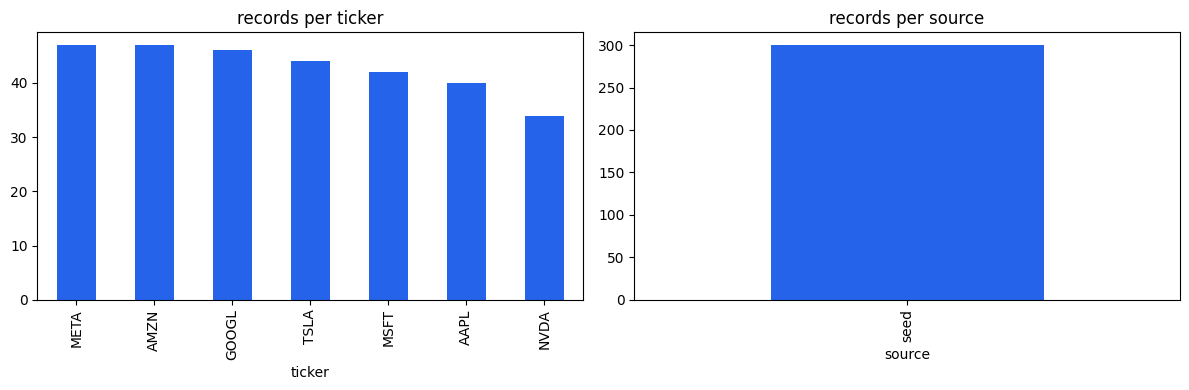

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df['ticker'].value_counts().plot.bar(ax=ax1, color='#2563eb')
ax1.set_title('records per ticker')
df['source'].value_counts().plot.bar(ax=ax2, color='#2563eb')
ax2.set_title('records per source')
plt.tight_layout()
plt.show()

## Text length distribution

The KS drift test runs against these distributions.

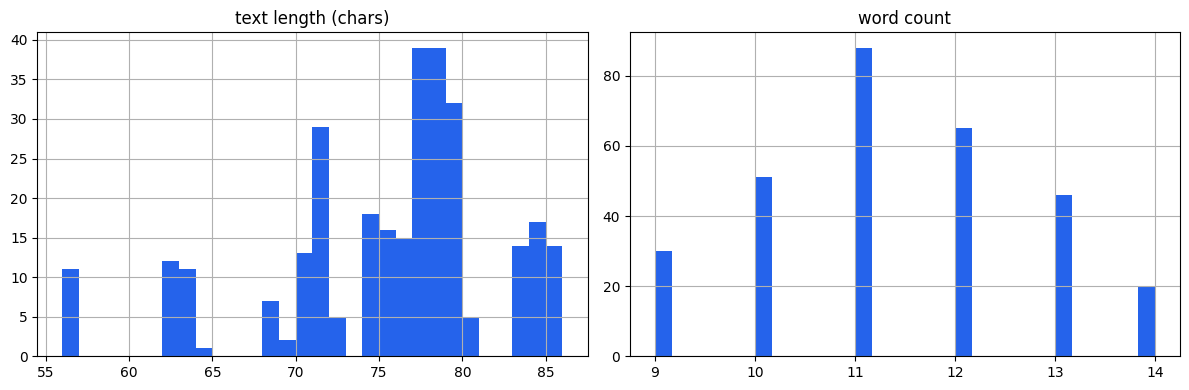

         text_len  word_count
count  300.000000  300.000000
mean    74.983333   11.353333
std      6.845870    1.371651
min     56.000000    9.000000
25%     71.000000   10.000000
50%     77.000000   11.000000
75%     79.000000   12.000000
max     86.000000   14.000000


In [4]:
df['text_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df['text_len'].hist(bins=30, ax=ax1, color='#2563eb')
ax1.set_title('text length (chars)')
df['word_count'].hist(bins=30, ax=ax2, color='#2563eb')
ax2.set_title('word count')
plt.tight_layout()
plt.show()

print(df[['text_len', 'word_count']].describe())

## Missing values

We expect `title`, `url`, `author` to be 100% null for the seed source (they're news/social-specific).

In [5]:
missing = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing.to_frame('pct_missing')

,pct_missing
title,100.0
url,100.0
author,100.0
id,0.0
source,0.0
ticker,0.0
text,0.0
timestamp,0.0
language,0.0
label,0.0


## Drift baselines — comparison with `artifacts/baselines.json`

This closes the loop: the EDA-computed numbers here should match what the drift detector compares live traffic against.

In [6]:
if BASELINES.exists():
    baselines = json.loads(BASELINES.read_text())
    print('Baseline numeric features:')
    for k, stats in baselines.get('features', {}).items():
        print(f'  {k:22} mean={stats["mean"]:.2f}  std={stats["std"]:.2f}  n={stats["count"]}')
    print('\nBaseline class balance:', baselines.get('distributions', {}).get('label'))
else:
    print('Baselines not generated yet — run `dvc repro eda_baselines`')

Baseline numeric features:
  text_length_chars      mean=74.98  std=6.85  n=300
  word_count             mean=11.35  std=1.37  n=300

Baseline class balance: {'positive': 0.366667, 'neutral': 0.316667, 'negative': 0.316667}


## Key takeaways

- **Class balance** is roughly 37 / 32 / 31 % (positive / neutral / negative) on the 300-record seed corpus. Template origins make the mean text length tightly clustered at ~75 chars — narrow distribution, which is what triggers the KS drift against the synthetic-normal baseline.
- **No NaN** in `id`, `source`, `ticker`, `text`, `timestamp`, `language`, `label`. `title`, `url`, `author` are 100% null by design for the seed source.
- **Per-ticker volume** is uneven (NVDA has ~33 records, MSFT ~42) — passes the JSD drift threshold currently but will tighten once live NewsAPI + Reddit adapters feed in.